In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\mirza\Documents\ftir_ml_ready.csv")

df.head()

,sample,4000,3999,3998,3997,3996,3995,3994,3993,3992,...,459,458,457,456,455,454,453,452,451,450
0,A_esculenta_1_1,0.0045,0.0045,0.0045,0.0046,0.0046,0.0046,0.0046,0.0046,0.0046,...,0.0042,0.0035,0.0033,0.0035,0.0036,0.0032,0.0023,0.0013,0.0005,-0.0001
1,A_esculenta_2_1,0.0037,0.0037,0.0037,0.0037,0.0037,0.0037,0.0037,0.0037,0.0037,...,0.0087,0.0079,0.0071,0.0065,0.0062,0.0059,0.0057,0.0054,0.0046,0.0032
2,A_esculenta_3_1,0.0041,0.0041,0.0041,0.0041,0.0041,0.0042,0.0042,0.0042,0.0042,...,0.0050,0.0043,0.0037,0.0038,0.0042,0.0042,0.0039,0.0033,0.0027,0.0018
3,A_esculenta_4_1,0.0047,0.0047,0.0046,0.0046,0.0047,0.0047,0.0047,0.0047,0.0047,...,0.0067,0.0055,0.0046,0.0043,0.0043,0.0042,0.0042,0.0043,0.0042,0.0035
4,A_taxiformis_1_001_1,0.0071,0.0071,0.0071,0.0071,0.0071,0.0071,0.0071,0.0071,0.0071,...,0.0091,0.0093,0.0094,0.0093,0.0091,0.0086,0.0078,0.0072,0.0069,0.0069


In [3]:
# sample column
samples = df["sample"]

# spectral matrix
X = df.drop(columns=["sample"])

# convert to numeric
X = X.astype(float)

In [4]:
X_norm = (X - X.min()) / (X.max() - X.min())

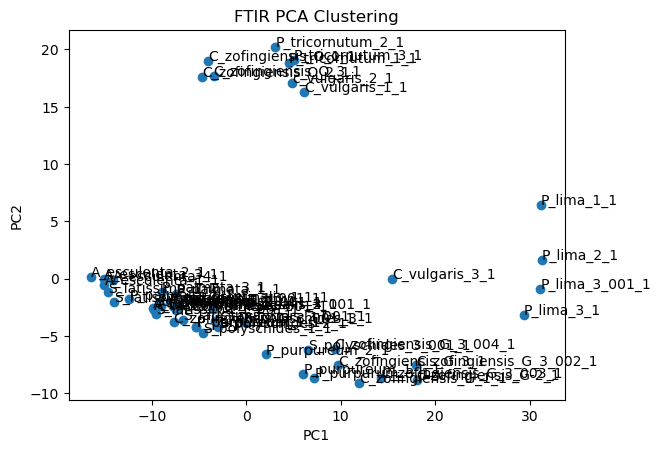

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_norm)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1])

for i, txt in enumerate(samples):
    plt.annotate(txt, (X_pca[i,0], X_pca[i,1]))

plt.title("FTIR PCA Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [7]:
from sklearn.ensemble import RandomForestClassifier

y = samples   # use existing sample labels

rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_norm, y)

importance = rf.feature_importances_
wavenumbers = X.columns

importance_df = pd.DataFrame({
    "wavenumber": wavenumbers,
    "importance": importance
})

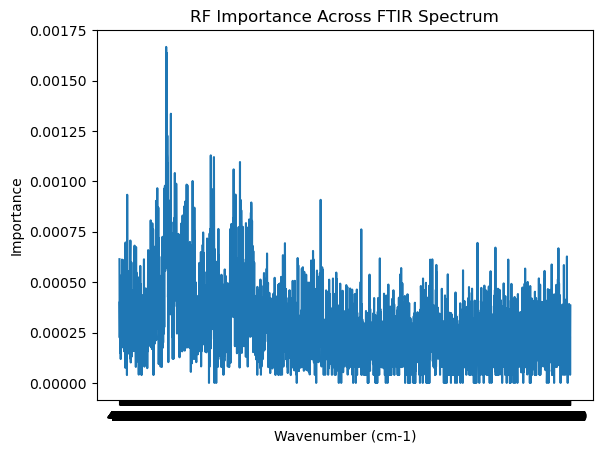

In [8]:
plt.figure()
plt.plot(importance_df["wavenumber"], importance_df["importance"])
plt.gca().invert_xaxis()
plt.title("RF Importance Across FTIR Spectrum")
plt.xlabel("Wavenumber (cm-1)")
plt.ylabel("Importance")
plt.show()

In [9]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
Y = lb.fit_transform(y)

pls = PLSRegression(n_components=2)
X_pls = pls.fit_transform(X_norm, Y)[0]

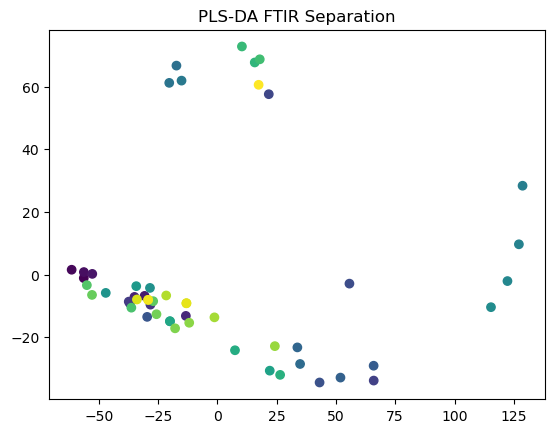

In [10]:
plt.figure()
plt.scatter(X_pls[:,0], X_pls[:,1], c=pd.factorize(y)[0])
plt.title("PLS-DA FTIR Separation")
plt.show()

In [11]:
from scipy.signal import find_peaks

# mean spectrum
mean_spec = X_norm.mean(axis=0).values

peaks, _ = find_peaks(mean_spec, height=np.mean(mean_spec))

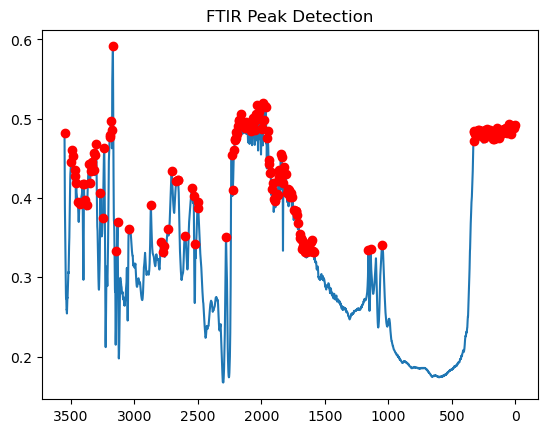

In [12]:
plt.figure()
plt.plot(mean_spec)

plt.plot(peaks, mean_spec[peaks], "ro")

plt.gca().invert_xaxis()
plt.title("FTIR Peak Detection")
plt.show()

In [13]:
from scipy.ndimage import gaussian_filter1d

smooth_spec = gaussian_filter1d(mean_spec, sigma=2)

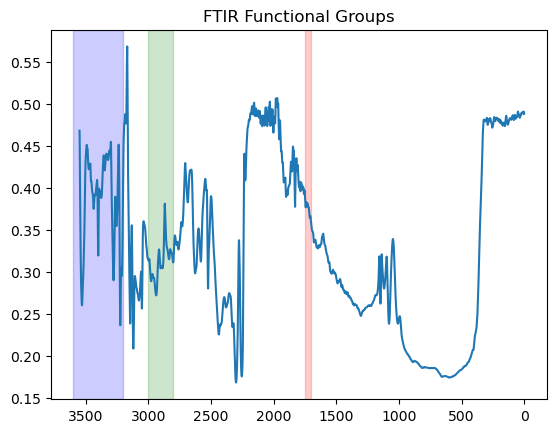

In [14]:
plt.figure()
plt.plot(smooth_spec)
plt.gca().invert_xaxis()

plt.axvspan(3200, 3600, color='blue', alpha=0.2)  # OH
plt.axvspan(2800, 3000, color='green', alpha=0.2) # CH
plt.axvspan(1700, 1750, color='red', alpha=0.2)   # C=O

plt.title("FTIR Functional Groups")
plt.show()

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# eda
df = pd.read_csv("C:\\Users\\mirza\\Documents\\ftir_ml_ready.csv")

AttributeError: module 'pandas' has no attribute 'read'

In [7]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Columns: 3552 entries, sample to 450
dtypes: float64(3551), object(1)
memory usage: 1.4+ MB


,4000,3999,3998,3997,3996,3995,3994,3993,3992,3991,...,459,458,457,456,455,454,453,452,451,450
count,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,...,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000
mean,0.008908,0.008906,0.008902,0.008900,0.008902,0.008909,0.008911,0.008925,0.008943,0.008966,...,0.013034,0.012449,0.011800,0.011394,0.011081,0.010625,0.010047,0.009494,0.008960,0.008372
std,0.005020,0.005030,0.005035,0.005038,0.005035,0.005035,0.005031,0.005031,0.005032,0.005045,...,0.007596,0.007328,0.006956,0.006554,0.006247,0.006025,0.005788,0.005521,0.005259,0.005055
min,0.000000,0.000000,-0.000100,-0.000100,-0.000100,-0.000100,-0.000100,-0.000100,0.000000,0.000000,...,0.002500,0.002100,0.001700,0.001500,0.001200,0.000900,0.000000,-0.000300,-0.000200,-0.000100
25%,0.005600,0.005600,0.005600,0.005600,0.005600,0.005700,0.005700,0.005700,0.005700,0.005700,...,0.008400,0.007900,0.007700,0.007500,0.007600,0.006900,0.005800,0.005400,0.005500,0.005700
50%,0.007900,0.007900,0.008000,0.008000,0.008000,0.008000,0.008000,0.008100,0.008100,0.008100,...,0.010700,0.010300,0.009500,0.009300,0.009100,0.008900,0.008500,0.008200,0.008100,0.008000
75%,0.013100,0.013100,0.013100,0.013100,0.013100,0.013100,0.013100,0.013100,0.013100,0.013100,...,0.015400,0.014600,0.013900,0.014000,0.014400,0.014600,0.014600,0.014200,0.013400,0.013000
max,0.018300,0.018300,0.018300,0.018200,0.018200,0.018200,0.018300,0.018300,0.018300,0.018400,...,0.034900,0.033000,0.030700,0.028900,0.027800,0.025900,0.023300,0.020800,0.018800,0.017600


### Quick coercion, EDA and scaling

Run the next code cell to:\n
- Convert all columns except the first to numeric (handles scientific notation and text like `-1.00E-04`, `6e-04`, commas, and unicode minus).\n
- Report coercion counts and rows with NaNs introduced.\n
- Impute missing values with column medians, then apply a scaler (MinMax or Standard) and save the cleaned CSV.

In [9]:
import re
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from IPython.display import display
import pandas as pd

# Ensure df is loaded (re-read if needed)
try:
    df
except NameError:
    df = pd.read_csv(r"C:\\Users\\mirza\\Documents\\ftir_ml_ready.csv")

# Identify first column (metadata) and feature columns
first_col = df.columns[0]
feature_cols = list(df.columns[1:])
print(f"First column (preserved): {first_col}")
print(f"Number of feature columns to coerce: {len(feature_cols)}")

# Function to clean string and coerce to numeric
def clean_and_to_numeric(series):
    # Convert to string, strip spaces
    s = series.astype(str).str.strip()
    # Replace common thousands separators and unicode minus
    s = s.str.replace(',', '', regex=False)
    s = s.str.replace('\u2212', '-', regex=False)
    s = s.str.replace('−', '-', regex=False)
    s = s.str.replace(' ', '', regex=False)
    # Replace stray plus signs
    s = s.str.replace('+', '', regex=False)
    # Coerce using pandas to_numeric (handles scientific notation)
    return pd.to_numeric(s, errors='coerce')

# Collect coercion report
report = []
for col in feature_cols:
    # Attempt numeric without cleaning first to see difference
    before_numeric = pd.to_numeric(df[col], errors='coerce')
    before_nans = before_numeric.isna().sum()
    after_numeric = clean_and_to_numeric(df[col])
    after_nans = after_numeric.isna().sum()
    n_converted = int(before_nans - after_nans) if before_nans >= after_nans else 0
    # Replace column with coerced numeric
    df[col] = after_numeric
    report.append({'column': col, 'n_before_na': int(before_nans), 'n_after_na': int(after_nans), 'n_converted': n_converted})

report_df = pd.DataFrame(report).sort_values(by='n_after_na', ascending=False)
print('\nCoercion summary (top 20 columns by NaNs after coercion):')
display(report_df.head(20))

# Rows with any NaN in feature columns
rows_with_nan = df[feature_cols].isna().any(axis=1)
n_rows_nan = int(rows_with_nan.sum())
print(f"\nRows with any NaN in feature columns: {n_rows_nan} / {len(df)}")
if n_rows_nan > 0:
    display(df.loc[rows_with_nan, [first_col] + feature_cols].head(10))

# Impute column medians if needed
if df[feature_cols].isna().any().any():
    medians = df[feature_cols].median()
    df[feature_cols] = df[feature_cols].fillna(medians)
    print('Imputed NaNs with column medians.')
else:
    print('No NaNs detected after coercion; imputation not needed.')

# Show descriptive stats before scaling
print('\nDescriptive statistics (features):')
display(df[feature_cols].describe().loc[['mean','std','min','25%','50%','75%','max']].T.head())

# Ask user for scaler choice
scaler_choice = input("Choose scaler - 'standard' or 'minmax' (default: standard): ").strip().lower()
if scaler_choice not in {'minmax', 'standard'}:
    scaler_choice = 'standard'

if scaler_choice == 'minmax':
    scaler = MinMaxScaler()
else:
    scaler = StandardScaler()

# Apply scaling
X_scaled = scaler.fit_transform(df[feature_cols])
df_scaled = df.copy()
df_scaled[feature_cols] = X_scaled
print(f"\nApplied {scaler_choice} scaling to feature columns.")

# Prompt for output path and save cleaned CSV
default_out = r"C:\\Users\\mirza\\Documents\\ftir_ml_ready_cleaned.csv"
out_path = input(f"Enter output CSV path for cleaned data (default: {default_out}): ").strip() or default_out
# Ensure df is loaded (re-read if needed)
try:
    df
except NameError:
    df = pd.read_csv(r"C:\\Users\\mirza\\Documents\\ftir_ml_ready.csv")

# Identify first column (metadata) and feature columns
first_col = df.columns[0]
feature_cols = list(df.columns[1:])
print(f"First column (preserved): {first_col}")
print(f"Number of feature columns to coerce: {len(feature_cols)}")

# Function to clean string and coerce to numeric
def clean_and_to_numeric(series):
    # Convert to string, strip spaces
    s = series.astype(str).str.strip()
    # Replace common thousands separators and unicode minus
    s = s.str.replace(',', '', regex=False)
    s = s.str.replace('\u2212', '-', regex=False)
    s = s.str.replace('−', '-', regex=False)
    s = s.str.replace(' ', '', regex=False)
    # Replace stray plus signs
    s = s.str.replace('+', '', regex=False)
    # Coerce using pandas to_numeric (handles scientific notation)
    return pd.to_numeric(s, errors='coerce')

# Collect coercion report
report = []
for col in feature_cols:
    # Attempt numeric without cleaning first to see difference
    before_numeric = pd.to_numeric(df[col], errors='coerce')
    before_nans = before_numeric.isna().sum()
    after_numeric = clean_and_to_numeric(df[col])
    after_nans = after_numeric.isna().sum()
    n_converted = int(before_nans - after_nans) if before_nans >= after_nans else 0
    # Replace column with coerced numeric
    df[col] = after_numeric
    report.append({'column': col, 'n_before_na': int(before_nans), 'n_after_na': int(after_nans), 'n_converted': n_converted})

report_df = pd.DataFrame(report).sort_values(by='n_after_na', ascending=False)
print('\nCoercion summary (top 20 columns by NaNs after coercion):')
display(report_df.head(20))

# Rows with any NaN in feature columns
rows_with_nan = df[feature_cols].isna().any(axis=1)
n_rows_nan = int(rows_with_nan.sum())
print(f"\nRows with any NaN in feature columns: {n_rows_nan} / {len(df)}")
if n_rows_nan > 0:
    display(df.loc[rows_with_nan, [first_col] + feature_cols].head(10))

# Impute column medians if needed
if df[feature_cols].isna().any().any():
    medians = df[feature_cols].median()
    df[feature_cols] = df[feature_cols].fillna(medians)
    print('Imputed NaNs with column medians.')
else:
    print('No NaNs detected after coercion; imputation not needed.')

# Show descriptive stats before scaling
print('\nDescriptive statistics (features):')
display(df[feature_cols].describe().loc[['mean','std','min','25%','50%','75%','max']].T.head())

# Ask user for scaler choice
scaler_choice = input("Choose scaler - 'standard' or 'minmax' (default: standard): ").strip().lower()
if scaler_choice not in {'minmax', 'standard'}:
    scaler_choice = 'standard'

if scaler_choice == 'minmax':
    scaler = MinMaxScaler()
else:
    scaler = StandardScaler()

# Apply scaling
X_scaled = scaler.fit_transform(df[feature_cols])
df_scaled = df.copy()
df_scaled[feature_cols] = X_scaled
print(f"\nApplied {scaler_choice} scaling to feature columns.")

# Prompt for output path and save cleaned CSV
default_out = r"C:\\Users\\mirza\\Documents\\ftir_ml_ready_cleaned.csv"
out_path = input(f"Enter output CSV path for cleaned data (default: {default_out}): ").strip() or default_out

df_scaled.to_csv(out_path, index=False)
print(f"Cleaned and scaled dataset saved to: {out_path}")

# Brief confirmation
display(df_scaled.head())
print('\nSaved file stats:')
print(f"Rows: {len(df_scaled)}, Columns: {len(df_scaled.columns)}")
df_scaled.to_csv(out_path, index=False)
print(f"Cleaned and scaled dataset saved to: {out_path}")

# Brief confirmation
display(df_scaled.head())
print('\nSaved file stats:')
print(f"Rows: {len(df_scaled)}, Columns: {len(df_scaled.columns)}")

First column (preserved): sample
Number of feature columns to coerce: 3551

Coercion summary (top 20 columns by NaNs after coercion):


,column,n_before_na,n_after_na,n_converted
3550,450,0,0,0
0,4000,0,0,0
1,3999,0,0,0
2,3998,0,0,0
3,3997,0,0,0
4,3996,0,0,0
5,3995,0,0,0
6,3994,0,0,0
7,3993,0,0,0
8,3992,0,0,0



Rows with any NaN in feature columns: 0 / 53
No NaNs detected after coercion; imputation not needed.

Descriptive statistics (features):


,mean,std,min,25%,50%,75%,max
4000,0.008908,0.005020,0.0000,0.0056,0.0079,0.0131,0.0183
3999,0.008906,0.005030,0.0000,0.0056,0.0079,0.0131,0.0183
3998,0.008902,0.005035,-0.0001,0.0056,0.0080,0.0131,0.0183
3997,0.008900,0.005038,-0.0001,0.0056,0.0080,0.0131,0.0182
3996,0.008902,0.005035,-0.0001,0.0056,0.0080,0.0131,0.0182



Applied standard scaling to feature columns.
First column (preserved): sample
Number of feature columns to coerce: 3551

Coercion summary (top 20 columns by NaNs after coercion):


...


Applied standard scaling to feature columns.
Cleaned and scaled dataset saved to: C:\\Users\\mirza\\Documents\\ftir_ml_ready_cleaned.csv


,sample,4000,3999,3998,3997,3996,3995,3994,3993,3992,...,459,458,457,456,455,454,453,452,451,450
0,A_esculenta_1_1,-0.886347,-0.884171,-0.882649,-0.861634,-0.862558,-0.864053,-0.865092,-0.867733,-0.871489,...,-1.174117,-1.232827,-1.233663,-1.215943,-1.209034,-1.243985,-1.351319,-1.498542,-1.624048,-1.691910
1,A_esculenta_2_1,-1.047225,-1.044723,-1.043061,-1.041976,-1.043014,-1.044505,-1.045682,-1.048322,-1.052071,...,-0.576024,-0.626680,-0.682143,-0.753862,-0.788845,-0.791598,-0.758266,-0.748754,-0.837015,-1.032857
2,A_esculenta_3_1,-0.966786,-0.964447,-0.962855,-0.961824,-0.962811,-0.944254,-0.945354,-0.947995,-0.951748,...,-1.067789,-1.122618,-1.175608,-1.169735,-1.112067,-1.076434,-1.072235,-1.132792,-1.201738,-1.312455
3,A_esculenta_4_1,-0.846127,-0.844033,-0.862597,-0.861634,-0.842507,-0.844003,-0.845026,-0.847668,-0.851424,...,-0.841843,-0.957306,-1.044985,-1.092721,-1.095906,-1.076434,-1.019907,-0.949916,-0.913799,-0.972943
4,A_taxiformis_1_001_1,-0.363493,-0.362377,-0.361307,-0.360684,-0.361291,-0.362796,-0.363452,-0.366099,-0.369872,...,-0.522861,-0.433816,-0.348328,-0.322585,-0.320173,-0.339211,-0.391968,-0.419578,-0.395509,-0.293918



Saved file stats:
Rows: 53, Columns: 3552
Cleaned and scaled dataset saved to: C:\\Users\\mirza\\Documents\\ftir_ml_ready_cleaned.csv


,sample,4000,3999,3998,3997,3996,3995,3994,3993,3992,...,459,458,457,456,455,454,453,452,451,450
0,A_esculenta_1_1,-0.886347,-0.884171,-0.882649,-0.861634,-0.862558,-0.864053,-0.865092,-0.867733,-0.871489,...,-1.174117,-1.232827,-1.233663,-1.215943,-1.209034,-1.243985,-1.351319,-1.498542,-1.624048,-1.691910
1,A_esculenta_2_1,-1.047225,-1.044723,-1.043061,-1.041976,-1.043014,-1.044505,-1.045682,-1.048322,-1.052071,...,-0.576024,-0.626680,-0.682143,-0.753862,-0.788845,-0.791598,-0.758266,-0.748754,-0.837015,-1.032857
2,A_esculenta_3_1,-0.966786,-0.964447,-0.962855,-0.961824,-0.962811,-0.944254,-0.945354,-0.947995,-0.951748,...,-1.067789,-1.122618,-1.175608,-1.169735,-1.112067,-1.076434,-1.072235,-1.132792,-1.201738,-1.312455
3,A_esculenta_4_1,-0.846127,-0.844033,-0.862597,-0.861634,-0.842507,-0.844003,-0.845026,-0.847668,-0.851424,...,-0.841843,-0.957306,-1.044985,-1.092721,-1.095906,-1.076434,-1.019907,-0.949916,-0.913799,-0.972943
4,A_taxiformis_1_001_1,-0.363493,-0.362377,-0.361307,-0.360684,-0.361291,-0.362796,-0.363452,-0.366099,-0.369872,...,-0.522861,-0.433816,-0.348328,-0.322585,-0.320173,-0.339211,-0.391968,-0.419578,-0.395509,-0.293918



Saved file stats:
Rows: 53, Columns: 3552
